<a href="https://colab.research.google.com/github/chuuxter/ALGORITMOS-DE-CLASIFICACION-COMPLETOS/blob/main/ALGORITMOS_DE_CLASIFICACION_(METRICAS_MEJORADAS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTAR LIBRERIAS NECESARIAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from google.colab import files

print(" Librerías cargadas correctamente")



 Librerías cargadas correctamente


In [2]:

# CARGA DE ARCHIVOS
# Subir el archivo desde tu computadora

uploaded = files.upload()

# Leer el archivo Excel
df = pd.read_excel('Dataset Modelo de Clasificación VARK .xlsx')

print("Dimensiones de tu dataset:")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print("\nPrimeras 10 filas:")
print(df.head(10))

print("\n📋 Columnas disponibles:")
print(df.columns.tolist())


Saving Dataset Modelo de Clasificación VARK .xlsx to Dataset Modelo de Clasificación VARK .xlsx
Dimensiones de tu dataset:
Filas: 218, Columnas: 72

Primeras 10 filas:
  GRADO SECCION  ORDEN  V1  A1  R1  K1  V2  A2  R2  ...  K15  V16  A16  R16  \
0   4TO       A     10   0   1   0   1   0   0   0  ...    1    0    1    1   
1   4TO       A      7   0   0   1   0   0   0   0  ...    1    0    0    0   
2   4TO       A     12   0   1   0   1   1   0   1  ...    0    0    1    0   
3   4TO       A     16   0   1   0   1   0   0   1  ...    0    0    0    1   
4   4TO       A     13   0   0   0   1   1   0   0  ...    0    0    0    0   
5   4TO       A      5   0   0   1   0   0   0   0  ...    1    0    0    0   
6   4TO       A      3   1   0   0   1   1   1   0  ...    0    1    0    0   
7   4TO       A     21   0   1   0   1   0   1   0  ...    1    0    0    1   
8   4TO       A     11   1   0   0   0   0   0   0  ...    1    0    0    0   
9   4TO       A     15   0   1   0   1  

In [3]:
# PREPARACION DEL DATASET PARA ALIMENTAR A LOS ALGORITMOS

# Eliminar columnas innecesarias
columnas_a_eliminar = ['GRADO', 'SECCION', 'ORDEN', 'COUNT V', 'COUNT A', 'COUNT R', 'COUNT K']
df_ml = df.drop(columns=columnas_a_eliminar, errors='ignore')

print("Columnas eliminadas: GRADO, SECCION, ORDEN, COUNT V, COUNT A, COUNT R, COUNT K")
print(f"Dataset para ML: {df_ml.shape[0]} filas, {df_ml.shape[1]} columnas")

# Mostrar fragmento con valores binarios (0 y 1)
print("\n" + "="*60)
print(" FRAGMENTO DEL DATASET (valores 0 y 1)")
print("="*60)
columnas_muestra = ['V1', 'A1', 'R1', 'K1', 'V2', 'A2', 'R2', 'K2', 'V16', 'A16', 'R16', 'K16', 'ESTILO']
muestra_df = df_ml[columnas_muestra].head(8)
print(muestra_df.to_string())

# Distribución de estilos
print("\nDISTRIBUCIÓN DE ESTILOS:")
print(df_ml['ESTILO'].value_counts())


Columnas eliminadas: GRADO, SECCION, ORDEN, COUNT V, COUNT A, COUNT R, COUNT K
Dataset para ML: 218 filas, 65 columnas

 FRAGMENTO DEL DATASET (valores 0 y 1)
   V1  A1  R1  K1  V2  A2  R2  K2  V16  A16  R16  K16         ESTILO
0   0   1   0   1   0   0   0   1    0    1    1    1              K
1   0   0   1   0   0   0   0   1    0    0    0    1              K
2   0   1   0   1   1   0   1   1    0    1    0    1  Mixto (V-A-K)
3   0   1   0   1   0   0   1   0    0    0    1    0              K
4   0   0   0   1   1   0   0   0    0    0    0    1              A
5   0   0   1   0   0   0   0   1    0    0    0    1              K
6   1   0   0   1   1   1   0   0    1    0    0    0    Mixto (V-K)
7   0   1   0   1   0   1   0   1    0    0    1    0              K

DISTRIBUCIÓN DE ESTILOS:
ESTILO
K                158
A                 29
R                 11
Mixto (A-K)        9
V                  4
Mixto (R-K)        3
Mixto (V-A-K)      1
Mixto (V-K)        1
Mixto (A-R-K)      

In [4]:
# DEFINICION DE FEATURES Y TARGET

# Separar features y target
features = [col for col in df_ml.columns if col != 'ESTILO']
X = df_ml[features]
y = df_ml['ESTILO']

print(f"Features: {len(features)} columnas")
print(f"Target: ESTILO")

Features: 64 columnas
Target: ESTILO


In [5]:
# SIMPLIFICACIÓN DE ESTILOS
def simplificar_estilo(estilo):
    if 'K' in estilo:
        return 'K'
    elif 'A' in estilo:
        return 'A'
    elif 'R' in estilo:
        return 'R'
    elif 'V' in estilo:
        return 'V'
    else:
        return estilo

df_ml['ESTILO_SIMPLIFICADO'] = df_ml['ESTILO'].apply(simplificar_estilo)

print("\nDistribución original:")
print(df_ml['ESTILO'].value_counts())

print("\nDistribución simplificada:")
print(df_ml['ESTILO_SIMPLIFICADO'].value_counts())



Distribución original:
ESTILO
K                158
A                 29
R                 11
Mixto (A-K)        9
V                  4
Mixto (R-K)        3
Mixto (V-A-K)      1
Mixto (V-K)        1
Mixto (A-R-K)      1
Mixto (V-R)        1
Name: count, dtype: int64

Distribución simplificada:
ESTILO_SIMPLIFICADO
K    173
A     29
R     12
V      4
Name: count, dtype: int64


In [6]:
# DEFINICIÓN DE X E Y FINALES
X = df_ml.drop(columns=['ESTILO', 'ESTILO_SIMPLIFICADO'])
y = df_ml['ESTILO_SIMPLIFICADO']

In [7]:
# BALANCEO DE CLASES
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("\n Clases balanceadas correctamente:")
print(pd.Series(y_res).value_counts())


 Clases balanceadas correctamente:
ESTILO_SIMPLIFICADO
K    173
A    173
R    173
V    173
Name: count, dtype: int64


In [8]:
#  DIVISIÓN EN TRAIN Y TEST
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# ENCODIFICACIÓN DE LABELS
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [10]:
#  TRATAMIENTO DE NULOS
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

In [18]:
#DEFINICIÓN DE MODELOS
modelos = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss')
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f"\nEntrenando modelo: {nombre} ...")

    # Usar datos escalados solo para SVM y KNN
    if nombre in ["SVM", "KNN"]:
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    resultados[nombre] = [acc, prec, rec, f1]


resultados_df = pd.DataFrame(resultados, index=['Accuracy', 'Precision', 'Recall', 'F1'])

print("\n Métricas de los modelos:")
print(resultados_df.T.round(4))


Entrenando modelo: Random Forest ...

Entrenando modelo: SVM ...

Entrenando modelo: KNN ...

Entrenando modelo: XGBoost ...

 Métricas de los modelos:
               Accuracy  Precision  Recall      F1
Random Forest    0.9856     0.9864  0.9856  0.9856
SVM              0.9928     0.9930  0.9928  0.9928
KNN              0.9137     0.9328  0.9137  0.9098
XGBoost          0.9712     0.9742  0.9712  0.9711


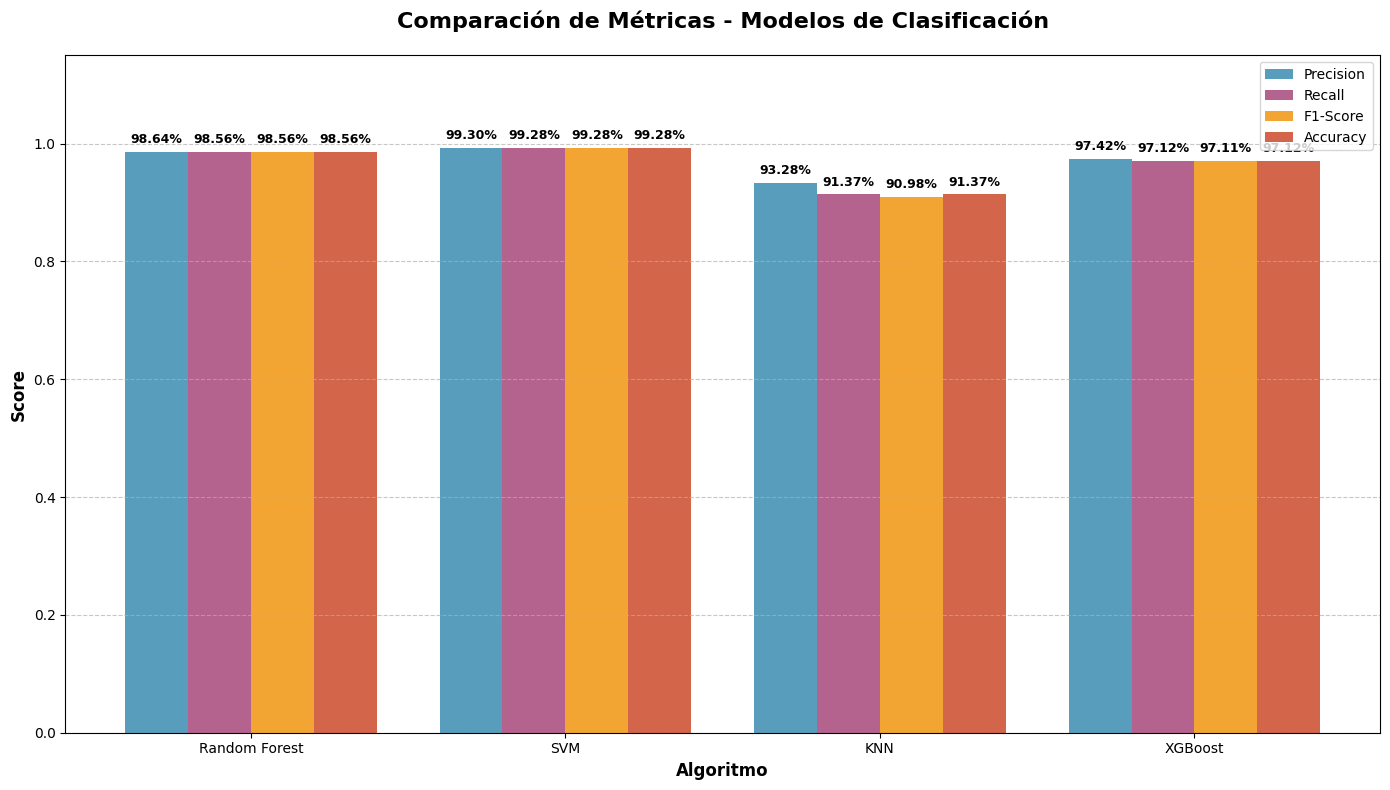

In [13]:
# ENTRENAMIENTO Y EVALUACIÓN DE MODELOS
results_df = resultados_df.T.reset_index()
results_df.rename(columns={'index': 'Algorithm', 'Precision': 'Precision', 'Recall': 'Recall', 'F1': 'F1-Score', 'Accuracy': 'Accuracy'}, inplace=True)

plt.figure(figsize=(14, 8))
x_pos = np.arange(len(results_df))
width = 0.2

metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, metric in enumerate(metrics):
    plt.bar(x_pos + i*width, results_df[metric], width, label=metric, color=colors[i], alpha=0.8)

    # Mostrar valores encima de las barras
    for j, value in enumerate(results_df[metric]):
        plt.text(j + i*width, value + 0.01, f'{value:.2%}', ha='center', va='bottom',
                 fontweight='bold', fontsize=9)

plt.title('Comparación de Métricas - Modelos de Clasificación', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Algoritmo', fontweight='bold', fontsize=12)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.xticks(x_pos + width*1.5, results_df['Algorithm'])
plt.ylim(0, 1.15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
# ==================  REPORTE DEL MEJOR MODELO ==================

best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Algorithm']
best_model = modelos[best_model_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"\nREPORTE DETALLADO - {best_model_name}")
print("="*70)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"🔹 Accuracy:  {acc:.2%}")
print(f"🔹 Precision: {prec:.2%}")
print(f"🔹 Recall:    {rec:.2%}")
print(f"🔹 F1-Score:  {f1:.2%}")

print(f"\n MÉTRICAS POR ESTILO INDIVIDUAL:")
try:
    labels = le.classes_
    print(classification_report(y_test, y_pred, target_names=labels, digits=4))
except:
    print(classification_report(y_test, y_pred, digits=4))


print(f"\n ¡ANÁLISIS COMPLETADO!")
print(f" Métricas promedio:")
print(f"   • Precision: {prec:.2%}")
print(f"   • Recall:    {rec:.2%}")
print(f"   • F1-Score:  {f1:.2%}")
print(f"   • Accuracy:  {acc:.2%}")



📊 REPORTE DETALLADO - SVM
🔹 Accuracy:  98.56%
🔹 Precision: 98.64%
🔹 Recall:    98.56%
🔹 F1-Score:  98.56%

 MÉTRICAS POR ESTILO INDIVIDUAL:
              precision    recall  f1-score   support

           A     0.9459    1.0000    0.9722        35
           K     1.0000    0.9412    0.9697        34
           R     1.0000    1.0000    1.0000        35
           V     1.0000    1.0000    1.0000        35

    accuracy                         0.9856       139
   macro avg     0.9865    0.9853    0.9855       139
weighted avg     0.9864    0.9856    0.9856       139


 ¡ANÁLISIS COMPLETADO!
 Métricas promedio:
   • Precision: 98.64%
   • Recall:    98.56%
   • F1-Score:  98.56%
   • Accuracy:  98.56%
